In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from lab.sinus_vs_square_hard.data import create_data
from quantumQRC.reservoir_computing import Reservoir
from quantum_simulation.configs import quantum_parameters_config, jpc_config_dudas
from quantum_simulation.jpc_chip import JpcChip

G:\Mon Drive\PycharmProjects\Quantum-Learn\quantum_simulation\history\photon_distribution.py:222: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(self.time_interval, jnp.sqrt(self.Delta_Na), label=r"$\Delta N_a$")


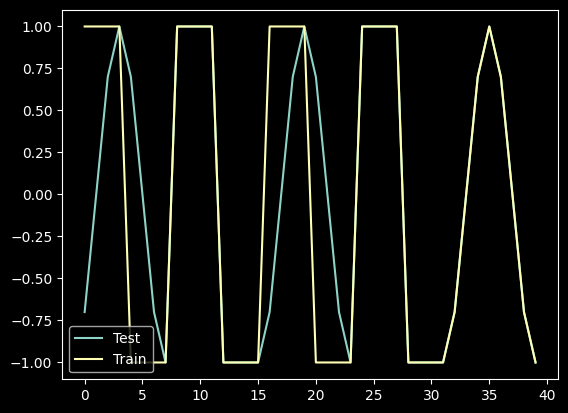

In [2]:
X_train_np, Y_train_np = create_data(5)
X_test_np, Y_test_np = create_data(5)

X_train, Y_train = jnp.array(X_train_np), jnp.array(Y_train_np)
X_test, Y_test = jnp.array(X_test_np), jnp.array(Y_test_np)

plt.plot(X_test, label='Test')
plt.plot(X_train, label='Train')
plt.legend()

In [3]:
jpc_config_dudas.summary()

JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=10000.0,
    OMEGA_B=9000.0,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=100,
    encoding_observable='epsilon',
    f_encoding=<function JPCConfig.<lambda> at 0x000001D785E2FCE0>
)


In [4]:
quantum_parameters = quantum_parameters_config
chip = JpcChip(jpc_config=jpc_config_dudas)

quantum_parameters.summary()

QuantumParameters(
    g_conv=700,
    g_sq=70,
    epsilon_a=65,
    epsilon_b=65,
    delta_a=10,
    delta_b=12
)


In [5]:
w = []
QRC_probas = Reservoir(w, chip=chip, mode='probas')
QRC_quadratures = Reservoir(w, chip=chip, mode='quadratures')

In [6]:
a_probas = QRC_probas.train(X=X_train,
                            Y=Y_train,
                            quantum_parameters_list=[quantum_parameters])
a_quadratures = QRC_quadratures.train(X=X_train,
                                      Y=Y_train,
                                      quantum_parameters_list=[quantum_parameters])

|██████████| 100.0% ◆ elapsed 01m06s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 01m08s ◆ remaining 0.00ms  


In [ ]:
Y_probas = QRC_probas.test(X=X_test,
                           Y=Y_test,
                           quantum_parameters_list=[quantum_parameters])

Y_quadratures = QRC_quadratures.test(X=X_test,
                                     Y=Y_test,
                                     quantum_parameters_list=[quantum_parameters])

|████████▉ |  89.9% ◆ elapsed 01m03s ◆ remaining 23.10s  

In [ ]:
treshold = 0
Y_corr_probas = 2 * (Y_probas[0] >= treshold) - 1
print(type(Y_corr_probas))
acc_probas = jnp.sum(Y_corr_probas == Y_test) / len(Y_test)
print('Accuracy probas = ', acc_probas * 1e2, '%') \
 \
    Y_corr_quadratures = 2 * (Y_quadratures[0] >= treshold) - 1
print(type(Y_corr_quadratures))
acc_quadratures = jnp.sum(Y_corr_quadratures == Y_test) / len(Y_test)
print('Accuracy probas = ', acc_quadratures * 1e2, '%')


In [ ]:
plt.scatter(range(len(Y_corr_probas)), Y_corr_probas, label='QRC probas', color='b')
plt.scatter(range(len(Y_corr_probas)), Y_corr_quadratures, label='QRC quadratures', color='g')
plt.plot(range(len(Y_test)), Y_test, label='Target', color='r')
plt.legend()
plt.show()

In [ ]:
plt.scatter(range(len(Y_probas[0])), Y_probas[0], label='QRC probas', color='b')
plt.scatter(range(len(Y_quadratures[0])), Y_quadratures[0], label='QRC quadratures', color='g')
plt.plot(range(len(Y_test)), Y_test, label='Target', color='r')
plt.legend()
plt.ylim([-2, 2])
plt.show()